In [1]:
import warnings

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

# Ignore matplotlib warnings
warnings.filterwarnings("ignore")

In [2]:
# Process raw time values from experiments
def process_time(df, time_var, time_limit):
    filtered_df = df[df["status"] == "OK"]  # Filter out TIMEOUTS and ERRORS
    filtered_df[time_var] = filtered_df[time_var].apply(lambda t: min(t, time_limit))  # Time is at most time limit
    return filtered_df


# Process raw data for Pokec experiments
def process_pokec(df):
    max_len = min(len(df), 12)
    df = df.iloc[:max_len, :]  # Remove extra rows
    df["n"] = list(range(1, max_len + 1))  # Add 'n' value to each row (upper bound for path length)
    return df


# Process raw data for Diamond experiments
def process_diamond(df):
    df = df.iloc[1:, :]  # Remove warmup row
    max_len = min(len(df), 40)
    df = df.iloc[:max_len, :]  # Remove extra rows
    df["n"] = list(range(1, max_len + 1))  # Add 'n' value to each row (number of diamonds)
    return df


# Filter rows to create a cleaner representation
def create_interval(df, step):
    max_idx = len(df)
    middle_points = []
    if step < max_idx:
        middle_points = list(range(step, max_idx, step))
    chosen_points = [1] + middle_points + [max_idx]
    return df[df.n.isin(chosen_points)]

In [3]:
# Create line plots
def generate_line_plots(parameter, group_filenames, data_func, labels, values, settings):
    # Prepare multiple line plots
    fig, axes = plt.subplots(
        1, len(group_filenames), sharey=values["share_y"], figsize=settings["figsize"]
    )  # Default Size: (6.4, 4.8)
    plt.subplots_adjust(wspace=0.1)

    # Support single plots
    if len(group_filenames) == 1:
        axes = [axes]

    # Title & Labels
    # fig.suptitle(labels['sup_title'], fontsize=12, fontweight='bold')
    # fig.supxlabel(labels['axes'][0], x=0.52, y=-0.05)
    axes[0].set_ylabel(labels["axes"][1])

    # Legend
    marker_symbols = ["o", "v", "X", "P", "^", "d", "D", "s", "p"]
    marker_function = lambda m, c: mlines.Line2D(
        [], [], marker=m, markersize=10, markeredgecolor="0.15", markerfacecolor=c, linestyle="", alpha=0.7
    )
    legend_handles = [
        marker_function(marker_symbols[color_idx], sb.color_palette()[color_idx])
        for color_idx in settings["legend_colors"]
    ]
    fig.legend(
        handles=legend_handles,
        labels=labels["legend"],
        ncol=settings["legend_cols"],
        loc="upper center",
        bbox_to_anchor=settings["legend_anchor"],
        frameon=False,
        columnspacing=0.8,
        handlelength=1.0,
        handletextpad=0.5,
    )

    # Create each line plot
    for idx, group in enumerate(group_filenames):
        # Load data from CSV files
        main_data = pd.DataFrame(
            {parameter: pd.Series(dtype="int"), "n": pd.Series(dtype="int"), "engine": pd.Series(dtype="int")}
        )
        for engine_idx, filename in enumerate(group):
            df = pd.read_csv(filename)
            df = data_func(df)  # Process raw data
            df = process_time(df, parameter, 60000)  # Process time values
            df["engine"] = engine_idx  # Add engine identifier
            if values["data_interval"] is not None:  # Create data interval for a more clean plot
                df = create_interval(df, values["data_interval"])
            main_data = pd.concat([main_data, df], ignore_index=True, sort=False)

        # Generate line plot from data
        colors = [sb.color_palette()[color_idx] for color_idx in values["colors"][idx]]
        chosen_markers = [marker_symbols[marker_idx] for marker_idx in values["colors"][idx]]
        g = sb.lineplot(
            x="n",
            y=parameter,
            data=main_data,
            hue="engine",
            style="engine",
            markers=chosen_markers,
            markersize=8,
            ax=axes[idx],
            legend=None,
            palette=colors,
            alpha=0.7,
        )
        g.set(xlabel=None)

        # Visualization settings

        # Title
        axes[idx].set_title(labels["sub_titles"][idx], fontsize=10)

        # X Axis
        x_ticks = values["x_ticks"]
        axes[idx].set_xticks(x_ticks)

        # Y Axis
        axes[idx].set_yscale(values["scale"])
        axes[idx].minorticks_off()
        axes[idx].grid(axis="y", linestyle="--")

    # Save image
    if settings["export"]:
        plt.savefig(settings["output_filename"], bbox_inches="tight")

    # Display
    plt.show()

In [4]:
# Global settings
global_scale = "log"  # Y axis scale, can be 'log' or 'linear'

# Engine names

# PG1: Neo4j
# PG2: Kuzu
# PG3: NebulaGraph
# S1: Jena
# S2: Virtuoso
# S3: Blazegraph

**Pokec All**

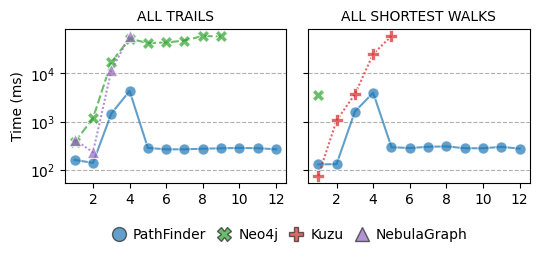

In [5]:
var = "enum_time_ms"
names = ["PathFinder", "Neo4j", "Kuzu", "NebulaGraph"]

# ALL TRAILS
files_a = ["Pokec/pokec_all_trails_bfs.csv", "Neo4j_new/pokec_all_trails.csv", "Old/Intro/All/nebula.csv"]
colors_a = [0, 2, 4]

# ALL SHORTEST WALKS
files_b = [
    "Pokec/pokec_all_shortest_walks_bfs.csv",
    "Neo4j_new/pokec_all_shortest_walks.csv",
    "Old/Intro/All Shortest/kuzu.csv",
]
colors_b = [0, 2, 3]

# Create line plots
sections = [files_a, files_b]
plot_labels = {
    "sup_title": "POKEC ALL",
    "sub_titles": ("ALL TRAILS", "ALL SHORTEST WALKS"),
    "axes": ("n", "Time (ms)"),
    "legend": names,
}
value_settings = {
    "scale": global_scale,
    "share_y": True,
    "data_interval": None,
    "x_ticks": [2, 4, 6, 8, 10, 12],
    "colors": [colors_a, colors_b],
}
general_settings = {
    "legend_cols": 4,
    "legend_colors": [0, 2, 3, 4],
    "figsize": (6, 2),
    "legend_anchor": (0.5, -0.05),
    "export": True,
    "output_filename": "pokec_all.pdf",
}
generate_line_plots(var, sections, process_pokec, plot_labels, value_settings, general_settings)

**Pokec Any**

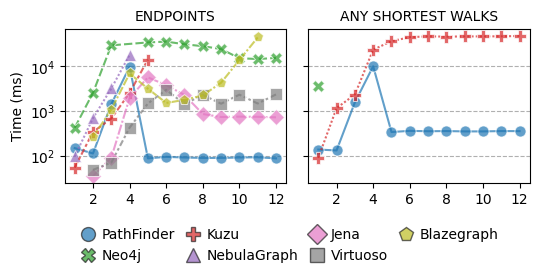

In [6]:
var = "enum_time_ms"
names = ["PathFinder", "Neo4j", "Kuzu", "NebulaGraph", "Jena", "Virtuoso", "Blazegraph"]

# ENDPOINTS
files_a = [
    "Pokec/pokec_endpoints_bfs.csv",
    "Neo4j_new/pokec_endpoints.csv",
    "Old/Pokec/Endpoints/nebula.csv",
    "Old/Pokec/Endpoints/kuzu.csv",
    "Old/Pokec/Endpoints/jena.csv",
    "Old/Pokec/Endpoints/virtuoso.csv",
    "Old/Pokec/Endpoints/blazegraph.csv",
]
colors_a = [0, 2, 4, 3, 6, 7, 8]

# ANY SHORTEST WALKS
files_b = [
    "Pokec/pokec_any_shortest_walks_bfs.csv",
    "Neo4j_new/pokec_any_shortest_walks.csv",
    "Old/Pokec/Any Shortest/kuzu.csv",
]
colors_b = [0, 2, 3]

# Create line plots
sections = [files_a, files_b]
plot_labels = {
    "sup_title": "POKEC ANY",
    "sub_titles": ("ENDPOINTS", "ANY SHORTEST WALKS"),
    "axes": ("n", "Time (ms)"),
    "legend": names,
}
value_settings = {
    "scale": global_scale,
    "share_y": True,
    "data_interval": None,
    "x_ticks": [2, 4, 6, 8, 10, 12],
    "colors": [colors_a, colors_b],
}
general_settings = {
    "legend_cols": 4,
    "legend_colors": [0, 2, 3, 4, 6, 7, 8],
    "figsize": (6, 2),
    "legend_anchor": (0.5, -0.05),
    "export": True,
    "output_filename": "pokec_any.pdf",
}
generate_line_plots(var, sections, process_pokec, plot_labels, value_settings, general_settings)

**Diamond Walks**

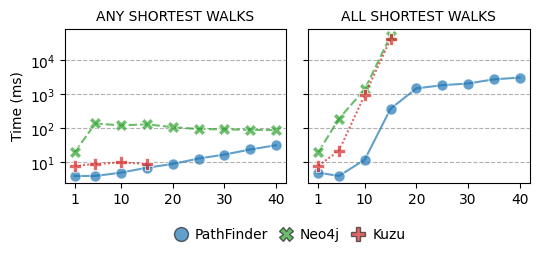

In [7]:
var = "enum_time_ms"
names = ["PathFinder", "Neo4j", "Kuzu"]

# ANY SHORTEST WALKS
files_a = [
    "Diamond/diamond_check_any_shortest_walks_bfs.csv",
    "Neo4j_new/diamond_any_shortest_walks.csv",
    "Old/Diamond/Any Shortest/kuzu.csv",
]
colors_a = [0, 2, 3]

# ALL SHORTEST WALKS
files_b = [
    "Diamond/diamond_check_all_shortest_walks_bfs.csv",
    "Neo4j_new/diamond_all_shortest_walks.csv",
    "Old/Diamond/All Shortest/kuzu.csv",
]
colors_b = [0, 2, 3]

# Create line plots
sections = [files_a, files_b]
plot_labels = {
    "sup_title": "DIAMOND WALKS",
    "sub_titles": ("ANY SHORTEST WALKS", "ALL SHORTEST WALKS"),
    "axes": ("n", "Time (ms)"),
    "legend": names,
}
value_settings = {
    "scale": global_scale,
    "share_y": True,
    "data_interval": 5,
    "x_ticks": [1, 10, 20, 30, 40],
    "colors": [colors_a, colors_b],
}
general_settings = {
    "legend_cols": 3,
    "legend_colors": [0, 2, 3],
    "figsize": (6, 2),
    "legend_anchor": (0.5, -0.05),
    "export": True,
    "output_filename": "diamond_walks.pdf",
}
generate_line_plots(var, sections, process_diamond, plot_labels, value_settings, general_settings)

**Diamond Trails**

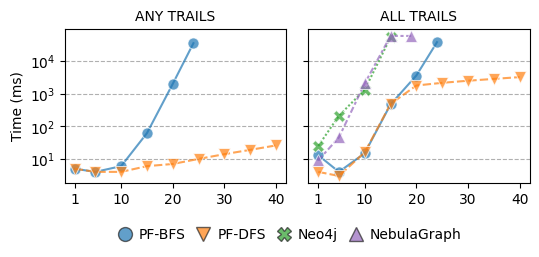

In [8]:
var = "enum_time_ms"
names = ["PF-BFS", "PF-DFS", "Neo4j", "NebulaGraph"]

# ANY TRAILS
files_a = ["Diamond/diamond_check_any_trails_bfs.csv", "Diamond/diamond_check_any_trails_dfs.csv"]
colors_a = [0, 1]

# ALL TRAILS
files_b = [
    "Diamond/diamond_check_all_trails_bfs.csv",
    "Diamond/diamond_check_all_trails_dfs.csv",
    "Neo4j_new/diamond_all_trails.csv",
    "Old/Diamond/All Trails/nebula.csv",
]
colors_b = [0, 1, 2, 4]

# Create line plots
sections = [files_a, files_b]
plot_labels = {
    "sup_title": "DIAMOND TRAILS",
    "sub_titles": ("ANY TRAILS", "ALL TRAILS"),
    "axes": ("n", "Time (ms)"),
    "legend": names,
}
value_settings = {
    "scale": global_scale,
    "share_y": True,
    "data_interval": 5,
    "x_ticks": [1, 10, 20, 30, 40],
    "colors": [colors_a, colors_b],
}
general_settings = {
    "legend_cols": 4,
    "legend_colors": [0, 1, 2, 4],
    "figsize": (6, 2),
    "legend_anchor": (0.5, -0.05),
    "export": True,
    "output_filename": "diamond_trails.pdf",
}
generate_line_plots(var, sections, process_diamond, plot_labels, value_settings, general_settings)